In [1]:
import jax 
import jax.numpy as jnp
import haiku as hk
import optax

from probjax.nn.transformers import Transformer
from probjax.nn.tokenizer import scalarize, ScalarTokenizer
from probjax.nn.helpers import GaussianFourierEmbedding, SinusoidalEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss

import matplotlib.pyplot as plt

from functools import partial

In [2]:
jax.devices()

I0000 00:00:1700767287.462541  259919 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.


[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [3]:
from sbibm import get_task

task = get_task("two_moons")
prior = task.get_prior_dist()
simulator = task.get_simulator()

thetas = prior.sample((100000,))
xs = simulator(thetas)

thetas = jnp.array(thetas)
xs = jnp.array(xs)


In [4]:
data = jnp.hstack([thetas, xs])
data = data[..., None]
num_nodes = data.shape[-2]
node_id = jnp.arange(num_nodes)

theta_dim = thetas.shape[-1]
x_dim = xs.shape[-1]

In [103]:

from probjax.distributions.sde import VPSDE, BaseSDE, VESDE
from probjax.distributions import Normal, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions.discrete import Empirical

p0 = Independent(Empirical(data), 2)
# beta_max = 10.
# beta_min = 0.1
sde = VESDE(p0, sigma_min=0.01, sigma_max=2.)
t = jnp.linspace(0,1,200)

data_mean = p0.mean

In [141]:

def model(t,data, data_id, condition_mask = None):
    dim = 50
    tokenizer = ScalarTokenizer(dim, len(node_id))
    time_embeder = SinusoidalEmbedding(128)
    
    # Embedding
    tokens = tokenizer(data_id,data)
    time = time_embeder(t[..., None])
    
    # Conditioning
    if condition_mask is not None:
        condition_token = hk.get_parameter("condition_token", shape=[1,1,dim], init=hk.initializers.RandomNormal(0.01))
        condition_mask = condition_mask.reshape(-1,data.shape[-2],1)
        tokens = tokens + condition_mask * condition_token
    
    # Forward pass 
    model = Transformer(num_heads=4, num_layers=4, attn_size=dim, widening_factor=5)
    h = model(tokens, context=time)
    output_weights = 1/jnp.sqrt(jnp.sum(sde.marginal_variance(t[...,None, None], x0=data_mean), axis=-2, keepdims=True) + 1e-5)
    out = hk.Linear(1)(h)
    
    return out * output_weights

init_fn, model_fn = hk.without_apply_rng(hk.transform(model))
params = init_fn(jax.random.PRNGKey(0), jnp.zeros(data[:10].shape[0],),data[:10], node_id,jnp.ones((10,theta_dim+x_dim)))
out = model_fn(params, 0.1*jnp.ones(data[:10].shape[0],),data[:10], node_id)


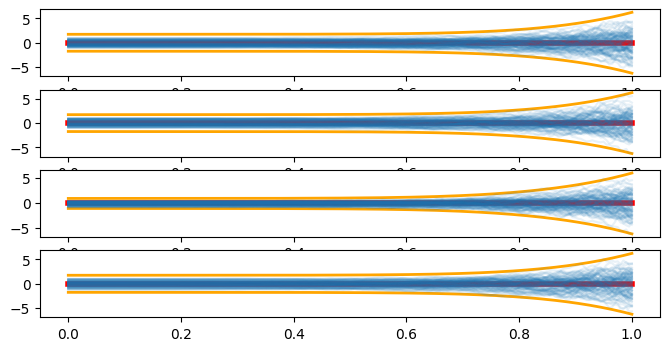

In [142]:
mean = sde.mean(t)
std = sde.stddev(t)
forward_samples = sde.sample(jax.random.PRNGKey(0), t, sample_shape=(100,))

fig, axes = plt.subplots(theta_dim+x_dim,1, figsize=(8, theta_dim+x_dim))
for i in range(len(axes)):
    _ = axes[i].plot(t, mean[:,i,0].T, lw=4, color="red")
    _ = axes[i].plot(t, mean[:,i,0].T + 3*std[:,i,0].T, lw=2, color="orange")
    _ = axes[i].plot(t, mean[:,i,0].T - 3*std[:,i,0].T, lw=2, color="orange")
    _ = axes[i].plot(t, forward_samples[...,i,0].T, color="C0", alpha=0.1)


In [143]:
# VPSDE 
T = 1.
T_min = 1e-6

def weight_fn(t):
    return sde.diffusion_matrix(t)**2

In [144]:
optimizer = optax.adam(5e-4)
opt_state = optimizer.init(params)

In [145]:
def loss_fn(params, key, data, node_id):
    key_times, key_loss, key_condition = jax.random.split(key,3)
    times = jax.random.uniform(key_times, (data.shape[0],), minval=T_min, maxval =1.)
    condition_mask = jax.random.choice(key_condition, jnp.stack([jnp.array([0]*(theta_dim + x_dim)), jnp.array([0]*theta_dim + [1]*x_dim)]), shape=(data.shape[0],), p = jnp.array([0.5,0.5]))
    loss = denoising_score_matching_loss(params, key_loss, times, data, condition_mask, node_id, model_fn = model_fn, mean_fn = sde.marginal_mean, std_fn=sde.marginal_stddev, weight_fn=weight_fn)
    return loss



@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, key, data, node_id):
    loss, grads = jax.value_and_grad(loss_fn)(params, key, data, node_id)

    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state
    

In [146]:
num_epochs = 5000
batch_size = 800
num_devices = jax.device_count()
batch_size_per_device = batch_size // num_devices
num_steps = data.shape[0] // batch_size + 1

In [147]:
replicated_params = jax.tree_map(lambda x: jnp.array([x] * num_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * num_devices), opt_state)

In [148]:

key = jax.random.PRNGKey(42)
for j in range(num_epochs):
    l = 0
    for i in range(num_steps):
        key, key_batch, key_update = jax.random.split(key, 3)
        data_batch = jax.random.choice(key_batch,data, shape=(num_devices, batch_size_per_device, ), axis=0)
        node_id_batch = jnp.repeat(node_id[None,...], num_devices, axis=0)
        loss, replicated_params, replicated_opt_state = update(replicated_params, replicated_opt_state, jax.random.split(key_update, (num_devices,)), data_batch, node_id_batch)
        l += loss[0] /num_steps
    if (j % 50) == 0:     
        print(l)

11500.274
8865.535
8770.809
8572.718
8494.042
8401.815
8343.0205
8288.64
8366.831
8330.048
8322.34
8364.182
8349.382
8420.149
8340.524
8215.821
8183.186
8237.788
8491.138
8315.814
8464.31
8219.508
8233.032
8364.869
8340.553
8261.663
8239.962
8201.477
8222.909
8373.214
8275.846
8196.317
8169.16
8139.7397
8238.957
8337.204
8301.023
8148.844
8152.6113
8298.136
8047.84
8176.7344
8231.644
8160.9927
8364.685
8194.598
8173.374
8127.6265
8286.916
8079.4087
8269.848
8171.9946
8039.8022
8056.5605
8345.211
8127.6978
8090.3447
8172.806
8142.983
8161.368
8257.137
8276.086
8200.433
8227.063
8244.888
8028.332
8208.326
8168.7656
8217.275
8199.127
8042.933
8096.3843
8229.962
8394.43
8408.747
8262.457
8182.64
8082.472
8210.473
8181.2964
8040.041
8259.502
8149.8745
8194.391
8174.8906
8082.67
8144.5073
8175.2236
8060.692
7977.787
8171.0596
8066.53
8067.566
8031.1973
8238.503
8249.067
8126.498
8230.696
8120.5166
8241.674


In [132]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [133]:

def sde_fn(condition_mask):

    def score_fn(t, x):
        x_embed = x.reshape(1, -1,1)
        score = model_fn(params, jnp.atleast_1d(t), x_embed, node_id, condition_mask.reshape(1,-1,1))
        return score.reshape(x.shape)

    def drift_backwards(t, x):
        t = (1- t)
        score = score_fn(t, x)
        drift = sde.drift(t, x) - sde.diffusion(t, x)**2 * score 
        drift = -drift * (1-condition_mask.reshape(x.shape))
        #print(drift.shape)
        return drift

    def diffusion_backwards(t, x):
        t = (1-t)
        diffusion = sde.diffusion(t, x) 
        return diffusion * (1-condition_mask.reshape(x.shape))

    return drift_backwards, diffusion_backwards

In [134]:
condition_value = data[0].reshape(1, -1 ,1)
condition_mask = jnp.array([0]*theta_dim + [1]*x_dim).reshape(1,-1,1)

In [135]:
from probjax.utils.sdeint import sdeint

In [136]:
def sample_fn(key, shape, x_o, condition_mask):
    key1, key2 = jax.random.split(key, 2)
    drift, diffusion = sde_fn(condition_mask)
    x_T = jax.random.normal(key1, shape + (len(node_id),)) #* marginal_std(jnp.zeros((1,)), 1.) + marginal_mean(jnp.zeros((1,)), 1.)
    condition_mask = condition_mask.reshape(1, -1, 1)
    x_T = x_T[..., None] * (1-condition_mask) + x_o * condition_mask
    x_T = x_T.reshape(shape + (theta_dim+x_dim,))
    keys = jax.random.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, drift, diffusion, x_T, jnp.linspace(0., 1-T_min, 2000))
    return ys

In [137]:
from sbi.analysis.sbc import c2st
import torch
import numpy as np

In [138]:

c2sts = []
for i in range(1,11):
    x_o = task.get_observation(i)
    samples_post = task.get_reference_posterior_samples(i)
    
    x_o = jnp.array(x_o)
    condition_value = condition_value.at[:,theta_dim:,0].set(x_o)
    samples_est = sample_fn(jax.random.PRNGKey(i), (10000,), condition_value, condition_mask)
    samples_est = samples_est[:, -1,:theta_dim]
    print(samples_est.shape)
    metric = c2st(torch.tensor(np.array(samples_est)), samples_post)
    print(metric)

(10000, 2)
tensor([0.7371])
(10000, 2)
tensor([0.7341])


KeyboardInterrupt: 

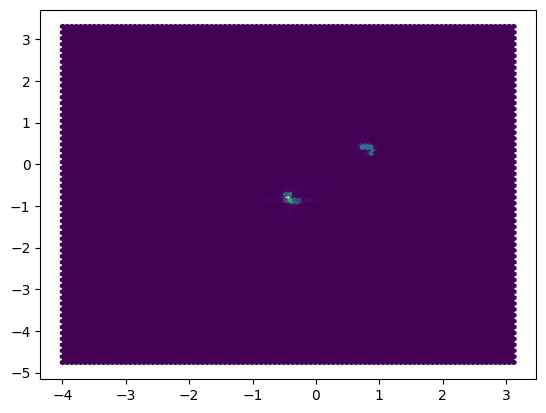

In [139]:
plt.hexbin(samples_est[:,0], samples_est[:,1])

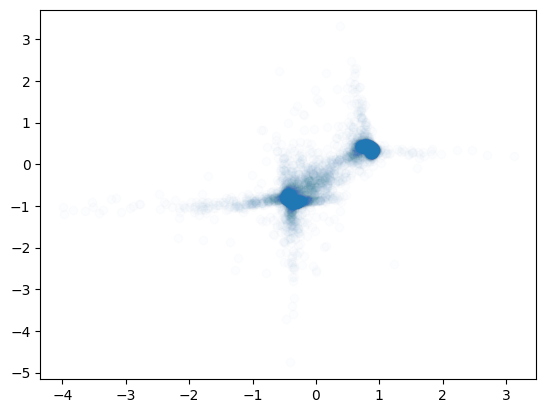

In [140]:
plt.scatter(samples_est[:,0], samples_est[:,1], alpha=0.01)

In [266]:
import sbi
from sbi.inference import SNPE, SNLE, SNRE

posterior = sbi.utils.posterior_nn(model='maf', 
                                    hidden_features=50, 
                                    hidden_layers=2,
                                    num_transforms=5)

inference = SNRE(prior)
density_estimator = inference.append_simulations(torch.as_tensor(np.array(thetas)), torch.as_tensor(np.array(xs))).train(training_batch_size=1000)
posterior = inference.build_posterior()

 Training neural network. Epochs trained: 71

KeyboardInterrupt: 

In [284]:
?inference.train

Signature:
inference.train(
    num_atoms: int = 10,
    training_batch_size: int = 50,
    learning_rate: float = 0.0005,
    validation_fraction: float = 0.1,
    stop_after_epochs: int = 20,
    max_num_epochs: int = 2147483647,
    clip_max_norm: Optional[float] = 5.0,
    resume_training: bool = False,
    discard_prior_samples: bool = False,
    retrain_from_scratch: bool = False,
    show_train_summary: bool = False,
    dataloader_kwargs: Optional[Dict] = None,
) -> torch.nn.modules.module.Module
Docstring:
Return classifier that approximates the ratio $p(\theta,x)/p(\theta)p(x)$.

Args:
    num_atoms: Number of atoms to use for classification.
    training_batch_size: Training batch size.
    learning_rate: Learning rate for Adam optimizer.
    validation_fraction: The fraction of data to use for validation.
    stop_after_epochs: The number of epochs to wait for improvement on the
        validation set before terminating training.
    max_num_epochs: Maximum number of epochs

In [263]:
?sbi.utils.posterior_nn

Signature:
sbi.utils.posterior_nn(
    model: str,
    z_score_theta: Optional[str] = 'independent',
    z_score_x: Optional[str] = 'independent',
    hidden_features: int = 50,
    num_transforms: int = 5,
    num_bins: int = 10,
    embedding_net: torch.nn.modules.module.Module = Identity(),
    num_components: int = 10,
    **kwargs,
) -> Callable
Docstring:
Returns a function that builds a density estimator for learning the posterior.

This function will usually be used for SNPE. The returned function is to be passed
to the inference class when using the flexible interface.

Args:
    model: The type of density estimator that will be created. One of [`mdn`,
        `made`, `maf`, `nsf`].
    z_score_theta: Whether to z-score parameters $\theta$ before passing them into
        the network, can take one of the following:
        - `none`, or None: do not z-score.
        - `independent`: z-score each dimension independently.
        - `structured`: treat dimensions as related, there

In [208]:

c2sts = []
for i in range(1,11):
    x_o = task.get_observation(i)
    samples_post = task.get_reference_posterior_samples(i)
    
    posterior = posterior.set_default_x(x_o)
    samples_est = posterior.sample((10000,))
    metric = c2st(torch.tensor(np.array(samples_est)), samples_post)
    print(metric)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

tensor([0.7176])


Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

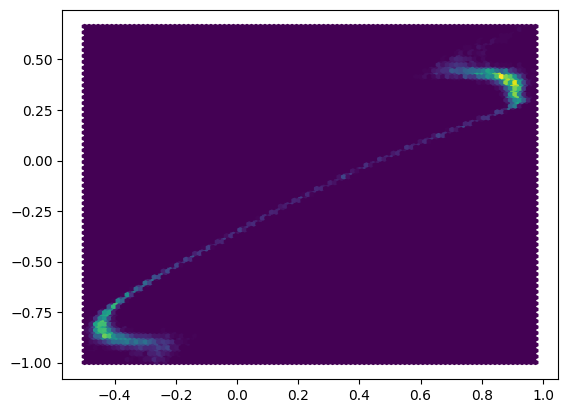

In [209]:
plt.hexbin(samples_est[:,0], samples_est[:,1])